# TP2 Deep Learning 

## 1 - Packages ##

Téléchargement des packages 
- [numpy](http://www.numpy.org) --> calcul numérique.
- [h5py](http://www.h5py.org) --> gestion des fichiers .H5
- [matplotlib](http://matplotlib.org) --> graphique en Python
- [PIL](https://python-pillow.org/) --> traitement des images (Rq : pour Python 3 : pip install pillow)
- [scipy](https://www.scipy.org/) --> calcul scientifique

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import scipy
from PIL import Image
import skimage
from skimage.transform import rescale, resize
import scipy
from lr_utils import load_dataset

## 2 - Problématique ##

**Base**: 

La base ("data.h5") contient:

    - base d'apprentissage (m_train) images étiquettées chat (y=1) ou non-chat (y=0)
    - base de test (m_test) images 
    - dim image (num_px, num_px, 3) 
    
**Objectif :**

Classifier les images selon leurs contenus chat/non-chat via un perceptron

In [25]:
# Téléchargement
train_set_x_orig, train_set_y, test_set_x_orig, test_set_y, classes = load_dataset()

y = [1]


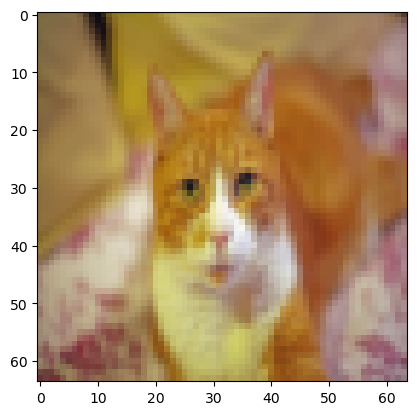

In [26]:
# Exemple : image numéro 25
# changer l'indice pour explorer la base
index = 24
plt.imshow(train_set_x_orig[index])
print ("y = " + str(train_set_y[:, index]))

Il est important de déterminer les dimensions de la base

**Exercise:** trouver les valeurs
    - m_train 
    - m_test 
    - num_px 

Remarque : utiliser la méthode (.shape)

In [27]:
## afficher les dimensions de la base d'pprentissage, test, 
None

### Votre code ### 
m_train = train_set_x_orig.shape[0]
m_test = test_set_x_orig.shape[0]
num_px = train_set_x_orig.shape[1]
### Fin ###

print ("m_train = " + str(m_train))
print ("m_test = " + str(m_test))
print ("longueur/largeur de l'image: num_px = " + str(num_px))

##Afficher les dimensions de tous les données nécessaires à la mise en oeuvre du perceptron
print("m_train = " + str(m_train))
print("m_test = " + str(m_test))
print("num_px = " + str(num_px))



m_train = 209
m_test = 50
longueur/largeur de l'image: num_px = 64
m_train = 209
m_test = 50
num_px = 64


**Mise en forme des données d'entrée**

- Mettre sous forme de vecteur les images de la base d'apprentissage 
- Utiliser la méthode (.reshape). pour passer d'une matrice (a,b,c,d) à une matrice (b$*$c$*$d,a) utiliser 
```python
X_flatten = X.reshape(X.shape[0], -1).T      # .T opérateur transposée
```

In [28]:
# Mise en forme

### Votre code### 
train_set_x_flatten = train_set_x_orig.reshape(m_train, -1).T
test_set_x_flatten = test_set_x_orig.reshape(m_test, -1).T
### Fin ###

print ("train_set_x_flatten shape: " + str(train_set_x_flatten.shape))
print ("train_set_y shape: " + str(train_set_y.shape))
print ("test_set_x_flatten shape: " + str(test_set_x_flatten.shape))
print ("test_set_y shape: " + str(test_set_y.shape))
print ("Vérification de reshape: " + str(train_set_x_flatten[0:5,0]))

train_set_x_flatten shape: (12288, 209)
train_set_y shape: (1, 209)
test_set_x_flatten shape: (12288, 50)
test_set_y shape: (1, 50)
Vérification de reshape: [17 31 56 22 33]


**Résultats attendus**: 

<table style="width:35%">
  <tr>
    <td>**train_set_x_flatten shape**</td>
    <td> (12288, 209)</td> 
  </tr>
  <tr>
    <td>**train_set_y shape**</td>
    <td>(1, 209)</td> 
  </tr>
  <tr>
    <td>**test_set_x_flatten shape**</td>
    <td>(12288, 50)</td> 
  </tr>
  <tr>
    <td>**test_set_y shape**</td>
    <td>(1, 50)</td> 
  </tr>
  <tr>
  <td>**Vérification après reshape**</td>
  <td>[17 31 56 22 33]</td> 
  </tr>
</table>

In [29]:
## Normalisation des données d'entrées
## Normaliser les image d'apprentissage 
train_set_x = train_set_x_flatten / 255.
test_set_x = test_set_x_flatten / 255.

## 3 - Architecture de l'alogorithme d'apprentissage ##

- A l'aide d'un schéma, représenter le perceptron ainsi les données d'apprentissage, les paramètres,... n'oublier pas les dimensions des objets manipulés. 


**Expressions mathématiques de l'alogorithme**:

Pour une instance $x^{(i)}$:
$$z^{(i)} = w^T x^{(i)} + b \tag{1}$$
$$\hat{y}^{(i)} = v^{(i)} = sigmoid(z^{(i)})\tag{2}$$ 
$$ \mathcal{L}(v^{(i)}, y^{(i)}) =  - y^{(i)}  \log(v^{(i)}) - (1-y^{(i)} )  \log(1-v^{(i)})\tag{3}$$

La fonction coût est calculée à partir de toutes les instances d'apprentissage:
$$ J = \frac{1}{m} \sum_{i=1}^m \mathcal{L}(v^{(i)}, y^{(i)})\tag{6}$$

**Etapes à suivre**:

- Initialisation les paramètres
- Apprentissage des paramètres du modèle
- Utilisation du modèle pour prédire s'il y en a un chat ou non dans une image
- Analyse des résultats

## 4 - Algorithme ##

### 4.1 - Fonction d'activation

**Exercice**: Implémenter la fonction sigmoïd "sigmoid()" : $sigmoid( w^T x + b) = \frac{1}{1 + e^{-(w^T x + b)}}$ 

In [30]:
# Fonction sigmoïde
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [31]:
# tester la fonction sigmoid
print ("sigmoid([0, 2]) = " + str(sigmoid(np.array([0,2]))))

sigmoid([0, 2]) = [0.5        0.88079708]


**Résultat attendus**: 

<table>
  <tr>
    <td>**sigmoid([0, 2])**</td>
    <td> [ 0.5         0.88079708]</td> 
  </tr>
</table>

### 4.2 - Initialisation des paramètres

**Exercice:** Imlémenter une fonction qui initialise les paramètres du modèles (W,b) à zéros "initialize_with_zeros(dim)" 

avec dim = taille de W

In [32]:
def initialize_with_zeros(dim):
    w = np.zeros((dim, 1))
    b = 0
    return w, b

In [33]:
# Tester la fonction d'initialisation
dim = 5  # Choisissez la dimension de w pour le test
w, b = initialize_with_zeros(dim)

print("w = " + str(w))
print("b = " + str(b))


w = [[0.]
 [0.]
 [0.]
 [0.]
 [0.]]
b = 0


### 4.3 - Propagation & Retropropagation 

**Exercice:** Implémenter la fonction `propagate()` qui calcul la fonction coût ainsi son Gradient.

Propagation:
- La valeur prédite $V = \sigma(w^T X + b) = (v^{(0)}, v^{(1)}, ..., v^{(m-1)}, v^{(m)})$
- La fonction coût $J = -\frac{1}{m}\sum_{i=1}^{m}y^{(i)}\log(v^{(i)})+(1-y^{(i)})\log(1-v^{(i)})$



$$ \frac{\partial J}{\partial w} = \frac{1}{m}X(V-Y)^T\tag{7}$$
$$ \frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^m (v^{(i)}-y^{(i)})\tag{8}$$


In [34]:
# fonction : propagate

def propagate(w, b, X, Y):
    """
    Fonction coût et son gradient

    Entrées:
    w --  (num_px * num_px * 3, 1)
    b --  (1,1)
    X --  images (num_px * num_px * 3, number of examples)
    Y --  étiquette

    Sorties:
    cost -- coût
    dw -- 
    db -- 
    """
    
    # Propagation 
    m = X.shape[1]
    V = sigmoid(np.dot(w.T, X) + b)
    cost = -1 / m * np.sum(Y * np.log(V) + (1 - Y) * np.log(1 - V))
    
    
    # Retropropagation 
    dw = 1 / m * np.dot(X, (V - Y).T)
    db = 1 / m * np.sum(V - Y)
    
    grads = {"dw": dw,
             "db": db}
    
    return grads, cost

In [35]:
# test de la fonction propagate
w, b, X, Y = np.array([[1],[2]]), 2, np.array([[1,2],[3,4]]), np.array([[1,0]])
grads, cost = propagate(w, b, X, Y)
print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))
print ("cost = " + str(cost))

dw = [[0.99993216]
 [1.99980262]]
db = 0.49993523062470574
cost = 6.000064773192205


**Résultats attendus**:

<table style="width:50%">
    <tr>
        <td>  ** dw **  </td>
        <td> [[ 0.99993216]
 [ 1.99980262]]</td>
    </tr>
    <tr>
        <td>  ** db **  </td>
        <td> 0.499935230625 </td>
    </tr>
    <tr>
        <td>  ** cost **  </td>
        <td> 6.000064773192205</td>
    </tr>

</table>

### d) Optimisation (apprentissage)

**Exercise:** Ecrire une fonction d'apprentissage ==> w et b en minimisant la fonction coût 



In [36]:
def optimize(w, b, X, Y, num_iterations, learning_rate, print_cost = False):
    """
    Arguments:
    w -- Poids synaptiques (num_px * num_px * 3, 1)
    b -- bias
    X -- images d'apprentissage (num_px * num_px * 3, number of examples)
    Y -- étiquette
    num_iterations -- nombre d'époques (epochs)  
    learning_rate -- 
    print_cost -- True impression de la fonction coût chaque 100 étapes
    
    Returns:
    params -- dictionaire contenant w et le bias b
    grads --  dictionaire contenant les gradients 
    costs --  liste de tous les coûts (sera utilisé ultérieurement).
    
    """
    
    costs = []
    for i in range(num_iterations):
        grads, cost = propagate(w, b, X, Y)
        
        dw = grads["dw"]
        db = grads["db"]
        
        w = w - learning_rate * dw
        b = b - learning_rate * db
        
        if i % 100 == 0:
            costs.append(cost)
            if print_cost:
                print(f"Coût après l'itération {i}: {cost}")
    
    params = {"w": w, "b": b}
    grads = {"dw": dw, "db": db}
    return params, grads, costs

In [37]:
#test de la fonction
params, grads, costs = optimize(w, b, X, Y, num_iterations= 100, learning_rate = 0.009, print_cost = False)

print ("w = " + str(params["w"]))
print ("b = " + str(params["b"]))
print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))

w = [[0.1124579 ]
 [0.23106775]]
b = 1.5593049248448891
dw = [[0.90158428]
 [1.76250842]]
db = 0.4304620716786828


**Resultats attendus**: 

<table style="width:40%">
    <tr>
       <td> **w** </td>
       <td>[[ 0.1124579 ]
 [ 0.23106775]] </td>
    </tr>    
    <tr>
       <td> **b** </td>
       <td> 1.55930492484 </td>
    </tr>
    <tr>
       <td> **dw** </td>
       <td> [[ 0.90158428]
 [ 1.76250842]] </td>
    </tr>
    <tr>
       <td> **db** </td>
       <td> 0.430462071679 </td>
    </tr>

</table>

### e) Prédiction

**Exercise:**  Implémenter une fonction "predict()" qui prédit l'étiquette d'une image.    
 
Deux étapes :

1. Calculer $\hat{Y} = V = \sigma(w^T X + b)$

2. Convertion 0 (si activation <= 0.5) ou 1 (si activation > 0.5), puis enregistrer les prédictions dans un vecteur `Y_prediction` 

In [38]:
def predict(w, b, X):
    '''
    Sortie:
    Y_prediction -- 
    '''
    m = X.shape[1]
    Y_prediction = np.zeros((1, m))
    A = sigmoid(np.dot(w.T, X) + b)
    
    for i in range(A.shape[1]):
        Y_prediction[0, i] = 1 if A[0, i] > 0.5 else 0
    return Y_prediction

In [39]:
#test de la fonction
print ("predictions = " + str(predict(w, b, X)))

predictions = [[1. 1.]]


**Résultat attendus**: 

<table style="width:30%">
    <tr>
         <td>
             **predictions**
         </td>
          <td>
            [[ 1.  1.]]
         </td>  
   </tr>

</table>


## 5 - Modèle global ##

Implémentation de l'ensemble du modèle

**Exercise:** Implementer le modèle en utilisant les notations suivantes :

    - Y_prediction : prédiction (base test) 
    - Y_prediction_train : prédiction (base apprentissage)
    - w, costs, grads sorties de optimize()

In [40]:
def model(X_train, Y_train, X_test, Y_test, num_iterations = 2000, learning_rate = 0.5, print_cost = False):
    """
    print_cost = True  -- affichage du coût chaque 100 itérations 
    
    d -- dictionaire contenant le modèle 
    """
    
    # initialisation 
    w, b = initialize_with_zeros(X_train.shape[0])

    # Gradient descendent 
    parameters, grads, costs = optimize(w, b, X_train, Y_train, num_iterations, learning_rate, print_cost)
    
    # extraction de w et b
    w = parameters["w"]
    b = parameters["b"]
    
    # Prediction test/apprentissage 
    Y_prediction_train = predict(w, b, X_train)
    Y_prediction_test = predict(w, b, X_test)

    
    # Affichage erreur de prédiction
    print("train accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100))
    print("test accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_test - Y_test)) * 100))

    
    d = {"costs": costs,
         "Y_prediction_test": Y_prediction_test, 
         "Y_prediction_train" : Y_prediction_train, 
         "w" : w, 
         "b" : b,
         "learning_rate" : learning_rate,
         "num_iterations": num_iterations}
    
    return d

In [41]:
# tester le modèle
d = model(train_set_x, train_set_y, test_set_x, test_set_y, num_iterations = 2000, learning_rate = 0.005, print_cost = True)

Coût après l'itération 0: 0.6931471805599453
Coût après l'itération 100: 0.5845083636993086
Coût après l'itération 200: 0.46694904094655476
Coût après l'itération 300: 0.37600686694802077
Coût après l'itération 400: 0.33146328932825136
Coût après l'itération 500: 0.30327306747438293
Coût après l'itération 600: 0.2798795865826048
Coût après l'itération 700: 0.2600421369258757
Coût après l'itération 800: 0.24294068467796615
Coût après l'itération 900: 0.22800422256726063
Coût après l'itération 1000: 0.2148195137844964
Coût après l'itération 1100: 0.20307819060644985
Coût après l'itération 1200: 0.19254427716706857
Coût après l'itération 1300: 0.18303333796883509
Coût après l'itération 1400: 0.17439859438448876
Coût après l'itération 1500: 0.16652139705400335
Coût après l'itération 1600: 0.15930451829756614
Coût après l'itération 1700: 0.15266732471296504
Coût après l'itération 1800: 0.1465422350398234
Coût après l'itération 1900: 0.14087207570310162
train accuracy: 99.04306220095694 %
te

**Resultats attendus**: 

<table style="width:40%">     
    <tr>
        <td> **Train Accuracy**  </td> 
        <td> 99.04306220095694 % </td>
    </tr>
    <tr>
        <td>**Test Accuracy** </td> 
        <td> 70.0 % </td>
    </tr>
</table> 

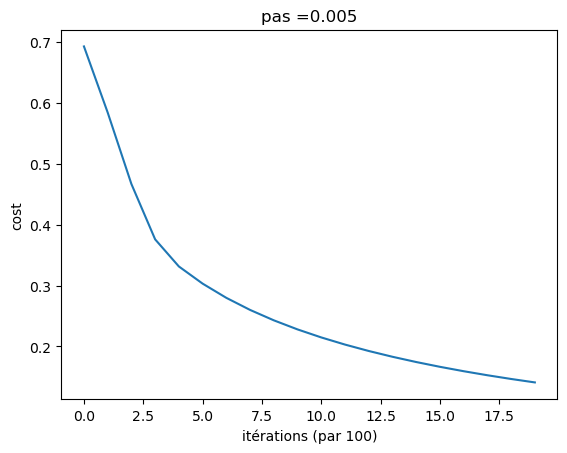

In [42]:
# figure : évolution du coût  
costs = np.squeeze(d['costs'])
plt.plot(costs)
plt.ylabel('cost')
plt.xlabel('itérations (par 100)')
plt.title("pas =" + str(d["learning_rate"]))
plt.show()

## 6 - Choix du pas d'adaptation ##

Le code suivant mets en évidence l'importance du choix du pas d'adaptation. Exécuter le code & interprter. 

learning rate is: 0.01
train accuracy: 99.52153110047847 %
test accuracy: 68.0 %

-------------------------------------------------------

learning rate is: 0.001
train accuracy: 88.99521531100478 %
test accuracy: 64.0 %

-------------------------------------------------------

learning rate is: 0.0001
train accuracy: 68.42105263157895 %
test accuracy: 36.0 %

-------------------------------------------------------



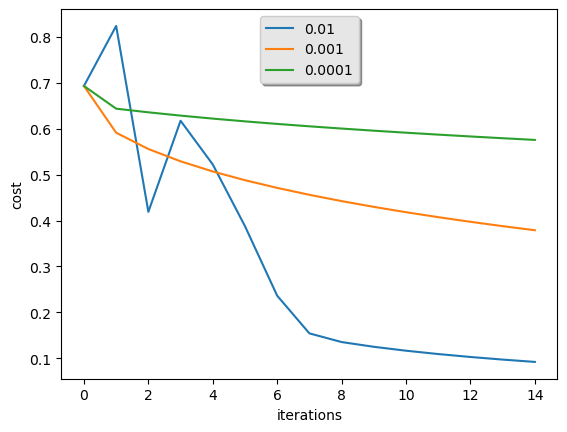

In [43]:
learning_rates = [0.01, 0.001, 0.0001]
models = {}
for i in learning_rates:
    print ("learning rate is: " + str(i))
    models[str(i)] = model(train_set_x, train_set_y, test_set_x, test_set_y, num_iterations = 1500, learning_rate = i, print_cost = False)
    print ('\n' + "-------------------------------------------------------" + '\n')

for i in learning_rates:
    plt.plot(np.squeeze(models[str(i)]["costs"]), label= str(models[str(i)]["learning_rate"]))

plt.ylabel('cost')
plt.xlabel('iterations')

legend = plt.legend(loc='upper center', shadow=True)
frame = legend.get_frame()
frame.set_facecolor('0.90')
plt.show()

## 7 - Tester vos propres images ##

y = 1.0, L'algorithme estime que "cat


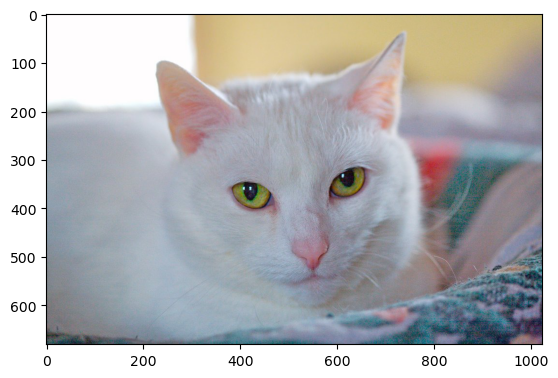

In [44]:
# Télécharger une image  
my_image = "im3.jpg"

# prédiction 
fname = "images/" + my_image
image = np.array(plt.imread(fname))
my_image = skimage.transform.resize(image, output_shape=(64, 64)).reshape((1, 64*64*3)).T
my_predicted_image = predict(d["w"], d["b"], my_image)

plt.imshow(image)
print("y = " + str(np.squeeze(my_predicted_image)) + ", L'algorithme estime que \"" + classes[int(np.squeeze(my_predicted_image)),].decode("utf-8"))

# **Optimisation Du TP1**

**Data Augmentation: This will artificially increase the size of the training dataset by applying transformations like rotations, flips, and shifts to the images, which can help the model generalize better.

Advanced Optimizers (Adam): Replace the standard gradient descent with the Adam optimizer, which adapts learning rates for each parameter and generally provides faster convergence.

Neural Networks (Multi-layer Perceptron): Instead of logistic regression, we will use a simple neural network with one hidden layer to improve performance.**

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.5566 - loss: 0.6896 - val_accuracy: 0.3400 - val_loss: 0.8216
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6606 - loss: 0.5928 - val_accuracy: 0.4000 - val_loss: 0.6829
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.7021 - loss: 0.5594 - val_accuracy: 0.5800 - val_loss: 0.7231
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7236 - loss: 0.4838 - val_accuracy: 0.9400 - val_loss: 0.4301
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.7425 - loss: 0.5138 - val_accuracy: 0.4400 - val_loss: 0.9310
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7700 - loss: 0.4111 - val_accuracy: 0.5800 - val_loss: 0.6692
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.7985 - loss: 0.4080 - val_accuracy: 0.9400 - val_loss: 0.3897
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.8078 - loss: 0.4053 - val_accuracy: 0.7600 - val_loss: 0.5357


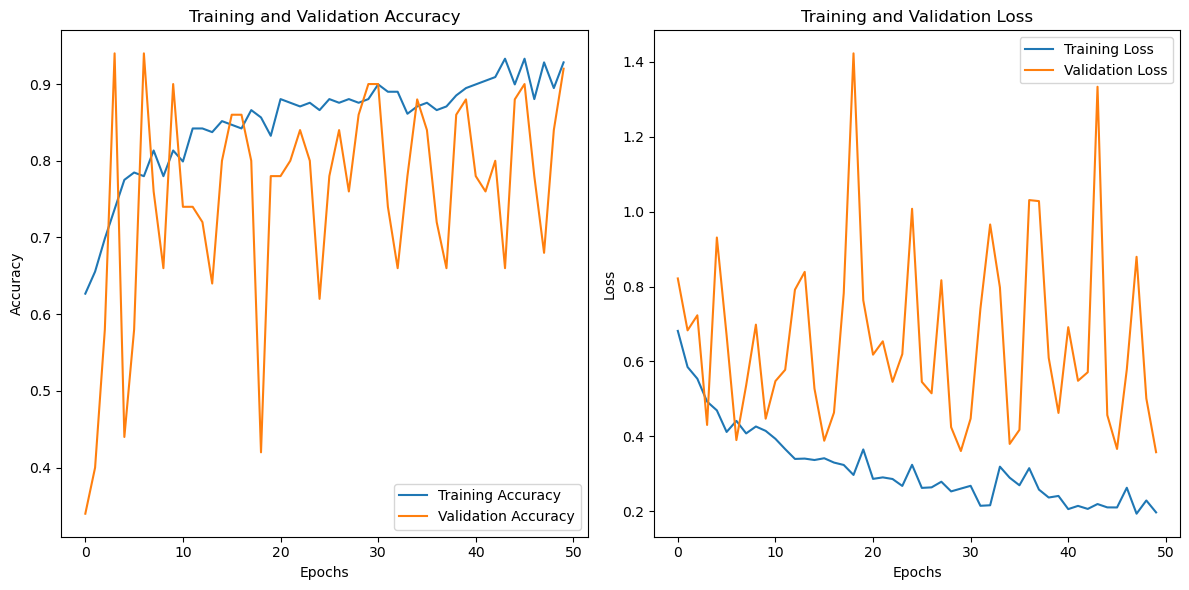

Test Loss: 0.3573048710823059
Test Accuracy: 0.9200000166893005


In [45]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Assuming you have the following datasets
# train_set_x_orig: images for training (shape: (209, 64, 64, 3))
# train_set_y: corresponding labels for training (shape: (209,))
# test_set_x_orig: images for testing (shape: (N, 64, 64, 3))
# test_set_y: corresponding labels for testing (shape: (N,))

# Step 1: Reshape labels to match the image data
train_set_y = train_set_y.reshape(-1)  # Ensures the shape is (209,)
test_set_y = test_set_y.reshape(-1)  # Similarly reshape test labels

# Step 2: Normalize the image data (important for neural networks)
train_set_x_orig = train_set_x_orig / 255.0
test_set_x_orig = test_set_x_orig / 255.0

# Step 3: One-hot encode the labels
train_set_y = to_categorical(train_set_y, num_classes=2)  # Change num_classes based on your dataset
test_set_y = to_categorical(test_set_y, num_classes=2)

# Step 4: Initialize the ImageDataGenerator for data augmentation
datagen = ImageDataGenerator(
    rotation_range=20,  # Randomly rotate images in the range of 20 degrees
    width_shift_range=0.2,  # Randomly shift images horizontally by 20%
    height_shift_range=0.2,  # Randomly shift images vertically by 20%
    shear_range=0.2,  # Apply shear transformations
    zoom_range=0.2,  # Random zoom
    horizontal_flip=True,  # Randomly flip images horizontally
    fill_mode='nearest'  # Fill any new pixels with the nearest value
)

# Fit the datagen on the training data
datagen.fit(train_set_x_orig)

# Step 5: Build a neural network model (e.g., CNN)
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')  # Assuming 2 classes for classification
])

# Step 6: Compile the model using Adam optimizer
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Step 7: Train the model with data augmentation
history = model.fit(datagen.flow(train_set_x_orig, train_set_y, batch_size=32),
                    epochs=50,  # Adjust number of epochs as needed
                    validation_data=(test_set_x_orig, test_set_y))

# Step 8: Plotting the results

# Plot training & validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Step 9: Evaluate the model
score = model.evaluate(test_set_x_orig, test_set_y, verbose=0)
print(f'Test Loss: {score[0]}')
print(f'Test Accuracy: {score[1]}')


**Data Augmentation:

The ImageDataGenerator is used to perform real-time data augmentation on the training data. It includes random rotations, shifts, shears, zoom, and horizontal flips to generate variations of the images and improve generalization.
Neural Network Model:

The model used here is a Convolutional Neural Network (CNN), which is effective for image classification tasks. The model includes 3 convolutional layers followed by max-pooling layers, a flatten layer, a fully connected dense layer, and a dropout layer to prevent overfitting. The output layer has 2 units (for binary classification) with the softmax activation function.
Adam Optimizer:

The Adam optimizer is used for training. It is one of the best optimizers in deep learning because it adapts the learning rate and works well for many tasks.
Training and Validation:

The model is trained using model.fit(), with the augmented data fed through datagen.flow(). The validation data is provided to monitor how well the model generalizes.
Visualization:

After training, accuracy and loss curves are plotted for both the training and validation sets. This helps you see how well the model has learned and whether there is overfitting (when the validation accuracy plateaus or drops while training accuracy increases).
Evaluation:

Finally, the model is evaluated on the test data to report the final loss and accuracy.
**